# Import bibliotek

In [94]:
import json
import string
import morfeusz2
import numpy as np
import pandas as pd
import operator as op
import itertools as it
from wordcloud import WordCloud
from matplotlib import pyplot as plt
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
from nltk.corpus import PlaintextCorpusReader
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Korpus dokumentów

In [95]:
corpus_dir = ("./my_original_summaries")
corpus = PlaintextCorpusReader(corpus_dir, ".*\.txt")
file_names = corpus.fileids()
file_names

['polska_ii_wojna_i_okupacja.txt',
 'polska_sredniowiecze.txt',
 'polska_wspolczesna.txt',
 'rozbiory_i_odbudowa.txt',
 'transformacja_1989_2004.txt']

# Wstępne przygotowanie dokumentów

In [96]:
documents = {}
for file in file_names:
    documents[file] = corpus.raw(file)
print(json.dumps(documents, indent = 4, ensure_ascii = False)) 

{
    "polska_ii_wojna_i_okupacja.txt": "Wyzwaniem egzystencjalnym dla II Rzeczypospolitej była II wojna światowa, rozpoczęta 1 września 1939 roku agresją niemiecką, a 17 września – sowiecką. Kampania wrześniowa, choć zakończyła się militarną klęską, pokazała heroizm polskich żołnierzy pod Westerplatte, Wizną czy Kockiem. Okupacja hitlerowska przyniosła systematyczne ludobójstwo: plan Generalplan Ost, egzekucje w Palmirach, zagładę Żydów w Treblince, Sobiborze i Auschwitz‑Birkenau. Równocześnie trwał opór cywilny i zbrojny: Związek Walki Zbrojnej, a później Armia Krajowa, przeprowadzały sabotaż i akcje dywersyjne (akcja pod Arsenałem, zamach na Kutscherę). W 1944 roku wybuchło Powstanie Warszawskie – symbol niezłomności, ale i tragizmu narodu pozostawionego bez pomocy aliantów. Na wschodzie Armia Andersa walczyła pod Monte Cassino, a Dywizjon 303 zapisał się złotymi literami w bitwie o Anglię. Sowieci, wyzwalając ziemie polskie, jednocześnie instalowali komunistyczne struktury władzy (

In [97]:
stoplist_file = open("./my_stopwords_pl.txt", "r", encoding="UTF-8")
stoplist = stoplist_file.read().splitlines()
stoplist_file.close()
stoplist = stoplist[4:]
stoplist

['ach',
 'acz',
 'aczkolwiek',
 'aj',
 'albo',
 'ale',
 'ależ',
 'ani',
 'aż',
 'bardziej',
 'bardzo',
 'bo',
 'bowiem',
 'by',
 'byli',
 'bynajmniej',
 'być',
 'był',
 'była',
 'było',
 'były',
 'będzie',
 'będą',
 'cali',
 'cała',
 'cały',
 'ci',
 'cię',
 'ciebie',
 'co',
 'cokolwiek',
 'coś',
 'czasami',
 'czasem',
 'czemu',
 'czy',
 'czyli',
 'daleko',
 'dla',
 'dlaczego',
 'dlatego',
 'do',
 'dobrze',
 'dokąd',
 'dość',
 'dużo',
 'dwa',
 'dwaj',
 'dwie',
 'dwoje',
 'dziś',
 'dzisiaj',
 'gdy',
 'gdyby',
 'gdyż',
 'gdzie',
 'gdziekolwiek',
 'gdzieś',
 'go',
 'i',
 'ich',
 'ile',
 'im',
 'inna',
 'inne',
 'inny',
 'innych',
 'iz',
 'ja',
 'jak',
 'jaka',
 'jakby',
 'jaki',
 'jakichś',
 'jakie',
 'jakiś',
 'jakiż',
 'jakkolwiek',
 'jako',
 'jakoś',
 'je',
 'jeden',
 'jedna',
 'jedno',
 'jednak',
 'jednakże',
 'jego',
 'jej',
 'jemu',
 'jest',
 'jestem',
 'jeszcze',
 'jeśli',
 'jeżeli',
 'już',
 'każdy',
 'kiedy',
 'kilka',
 'kimś',
 'kto',
 'ktokolwiek',
 'ktoś',
 'która',
 'które',
 

In [98]:
def lemmatize(text):
    morf = morfeusz2.Morfeusz()
    segments = it.groupby(morf.analyse(text), op.itemgetter(0,1))
    def disambiguate(group):
        pairs = ((len(descr), lemma) for _, _, (_, lemma, descr, _, _, ) in group)
        perpl, lemma = min(pairs)
        return lemma.split(":")[0]
    lemmas = (disambiguate(group) for key, group in segments)
    return " ".join(filter(str.isalpha, lemmas))

In [99]:
for key in documents:
    documents[key] = documents[key].lower()
    documents[key] = "".join([char for char in documents[key] if char not in string.punctuation])
    documents[key] = lemmatize(documents[key])
    documents[key] = " ".join([word for word in word_tokenize(documents[key], language="polish") if word not in stoplist])
print(json.dumps(documents, indent=4, ensure_ascii=False))  

{
    "polska_ii_wojna_i_okupacja.txt": "wyzwanie egzystencjalny ii rzeczpospolita ii wojna światowy rozpocząć września rok agresja niemiecki września sowiecki kampania wrześniowy choć zakończyć się militarny klęska pokazać heroizm polski żołnierz pod Westerplatte Wizna Kocek okupacja hitlerowski przynieść systematyczny ludobójstwo plan generalplan ost egzekucja w Palmiry zagłada żyd w Treblinka Sobibór równocześnie trwać opora cywilny zbrojny związka walka zbrojny późno armia krajowy przeprowadzać sabotaż akcja dywersyjny akcja pod arsenał zamach na kutscherę w rok wybuchnąć powstać warszawski symbol niezłomność tragizm naród pozostawić bez pomoc aliant na wschód armia Anders walczyć pod Monte Cassino dywizjon zapisać się złoty litera w bitwa o Anglia Sowiet wyzwalać ziemia polski jednocześnie instalować komunistyczny struktura władza PKWN NKWD koniec wojna oznaczać przesunąć granica na linia odra nysa wysiedlić ludność oraz utrata kres bilans okupacja to około milion obywatel zabita 

# Utworzenie macierzy częstości 

In [100]:
docs = pd.DataFrame.from_dict(documents, orient = 'index')
docs.columns = ['content']
docs

,content
polska_ii_wojna_i_okupacja.txt,wyzwanie egzystencjalny ii rzeczpospolita ii w...
polska_sredniowiecze.txt,polski w okres średniowiecze wykształcić funda...
polska_wspolczesna.txt,w XXI wiek polski funkcjonować średnia wielkoś...
rozbiory_i_odbudowa.txt,trzy rozbiór dokonany przez Rosja Prus Austria...
transformacja_1989_2004.txt,latać to okres głęboki transformacja ustrojowy...


In [101]:
count_vectorizer = CountVectorizer()
counts_tf = count_vectorizer.fit_transform(docs['content'])
counts_tf.toarray()

array([[0, 1, 0, ..., 0, 1, 1],
       [1, 0, 1, ..., 0, 0, 0],
       [1, 1, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5, 523))

In [102]:
tfidf_vectorizer = TfidfVectorizer()
counts_tfidf = tfidf_vectorizer.fit_transform(docs['content'])
counts_tfidf.toarray()

array([[0.        , 0.06777503, 0.        , ..., 0.        , 0.0840054 ,
        0.0840054 ],
       [0.07075503, 0.        , 0.08769903, ..., 0.        , 0.        ,
        0.        ],
       [0.06804934, 0.06804934, 0.        , ..., 0.0843454 , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(5, 523))

# Chmury tagów

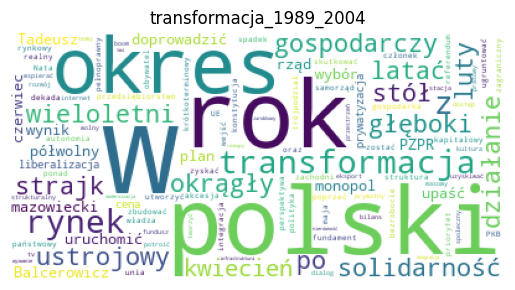

In [103]:
wordcloud = WordCloud(background_color = "white", max_words = 5000, contour_width = 3, contour_color = "steelblue")
for index, row in docs.iterrows():
    wordcloud.generate(row['content'])
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.title(index.replace(".txt", ""))
    plt.savefig("./wordclouds/{}".format(index.replace(".txt", ".png")))

# Topic modelling

In [104]:
def plot_top_words(model, feature_names, n_top_words, title, subplots):
    fig, axes = plt.subplots(*subplots, figsize=(30, 15), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[-n_top_words:]
        top_features = feature_names[top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f"Topic {topic_idx + 1}", fontdict={"fontsize": 30})
        ax.tick_params(axis = "both", which = "major", labelsize = 20)
        for i in "top right left".split():
            ax.spines[i].set_visible(False)
        fig.suptitle(title, fontsize = 40)

    plt.subplots_adjust(top = 0.90, bottom = 0.05, wspace = 0.90, hspace = 0.3)
    plt.savefig(f"./my_topics/{title}.png")

In [105]:
n_components = 3
feature_names = count_vectorizer.get_feature_names_out()
n_top_features = 20
size = [1, 3]

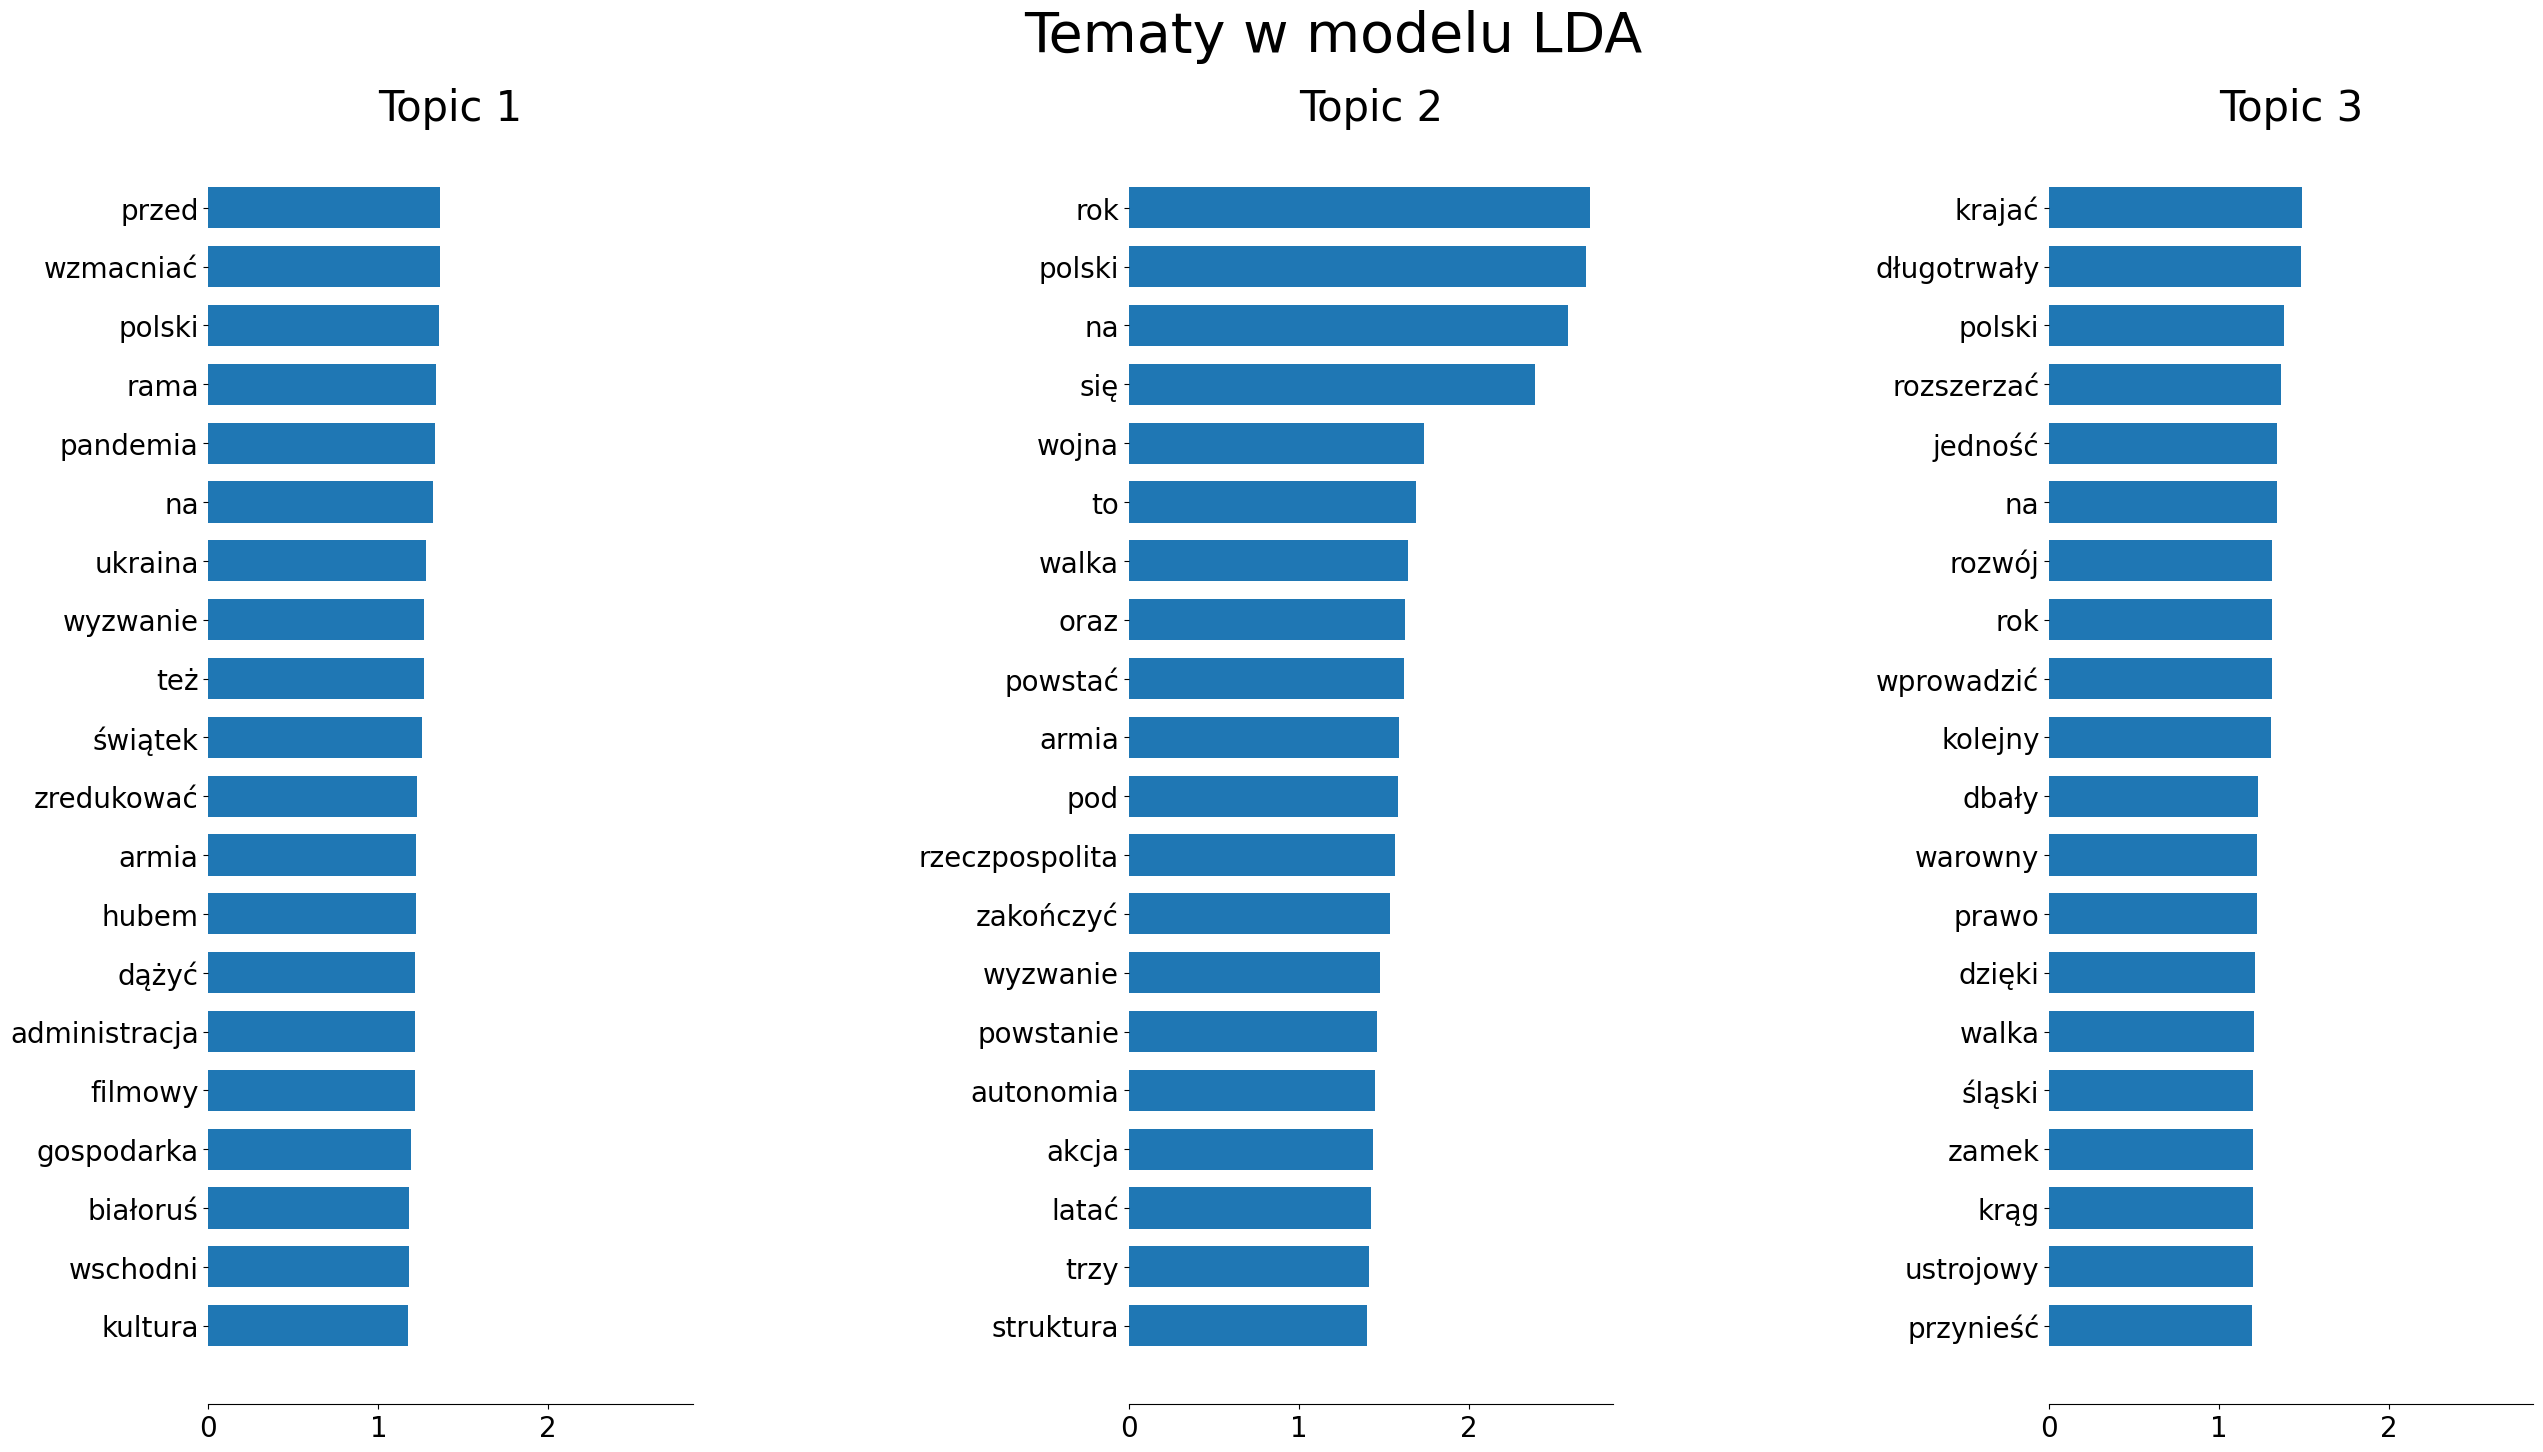

In [106]:
lda = LatentDirichletAllocation(
    n_components = n_components, 
    max_iter = 5, 
    learning_method = 'online', 
    learning_offset = 50,
    random_state = 0
)
lda.fit(counts_tf)
plot_top_words(lda, feature_names, n_top_features, "Tematy w modelu LDA", size)

d:\programowanie\TM\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


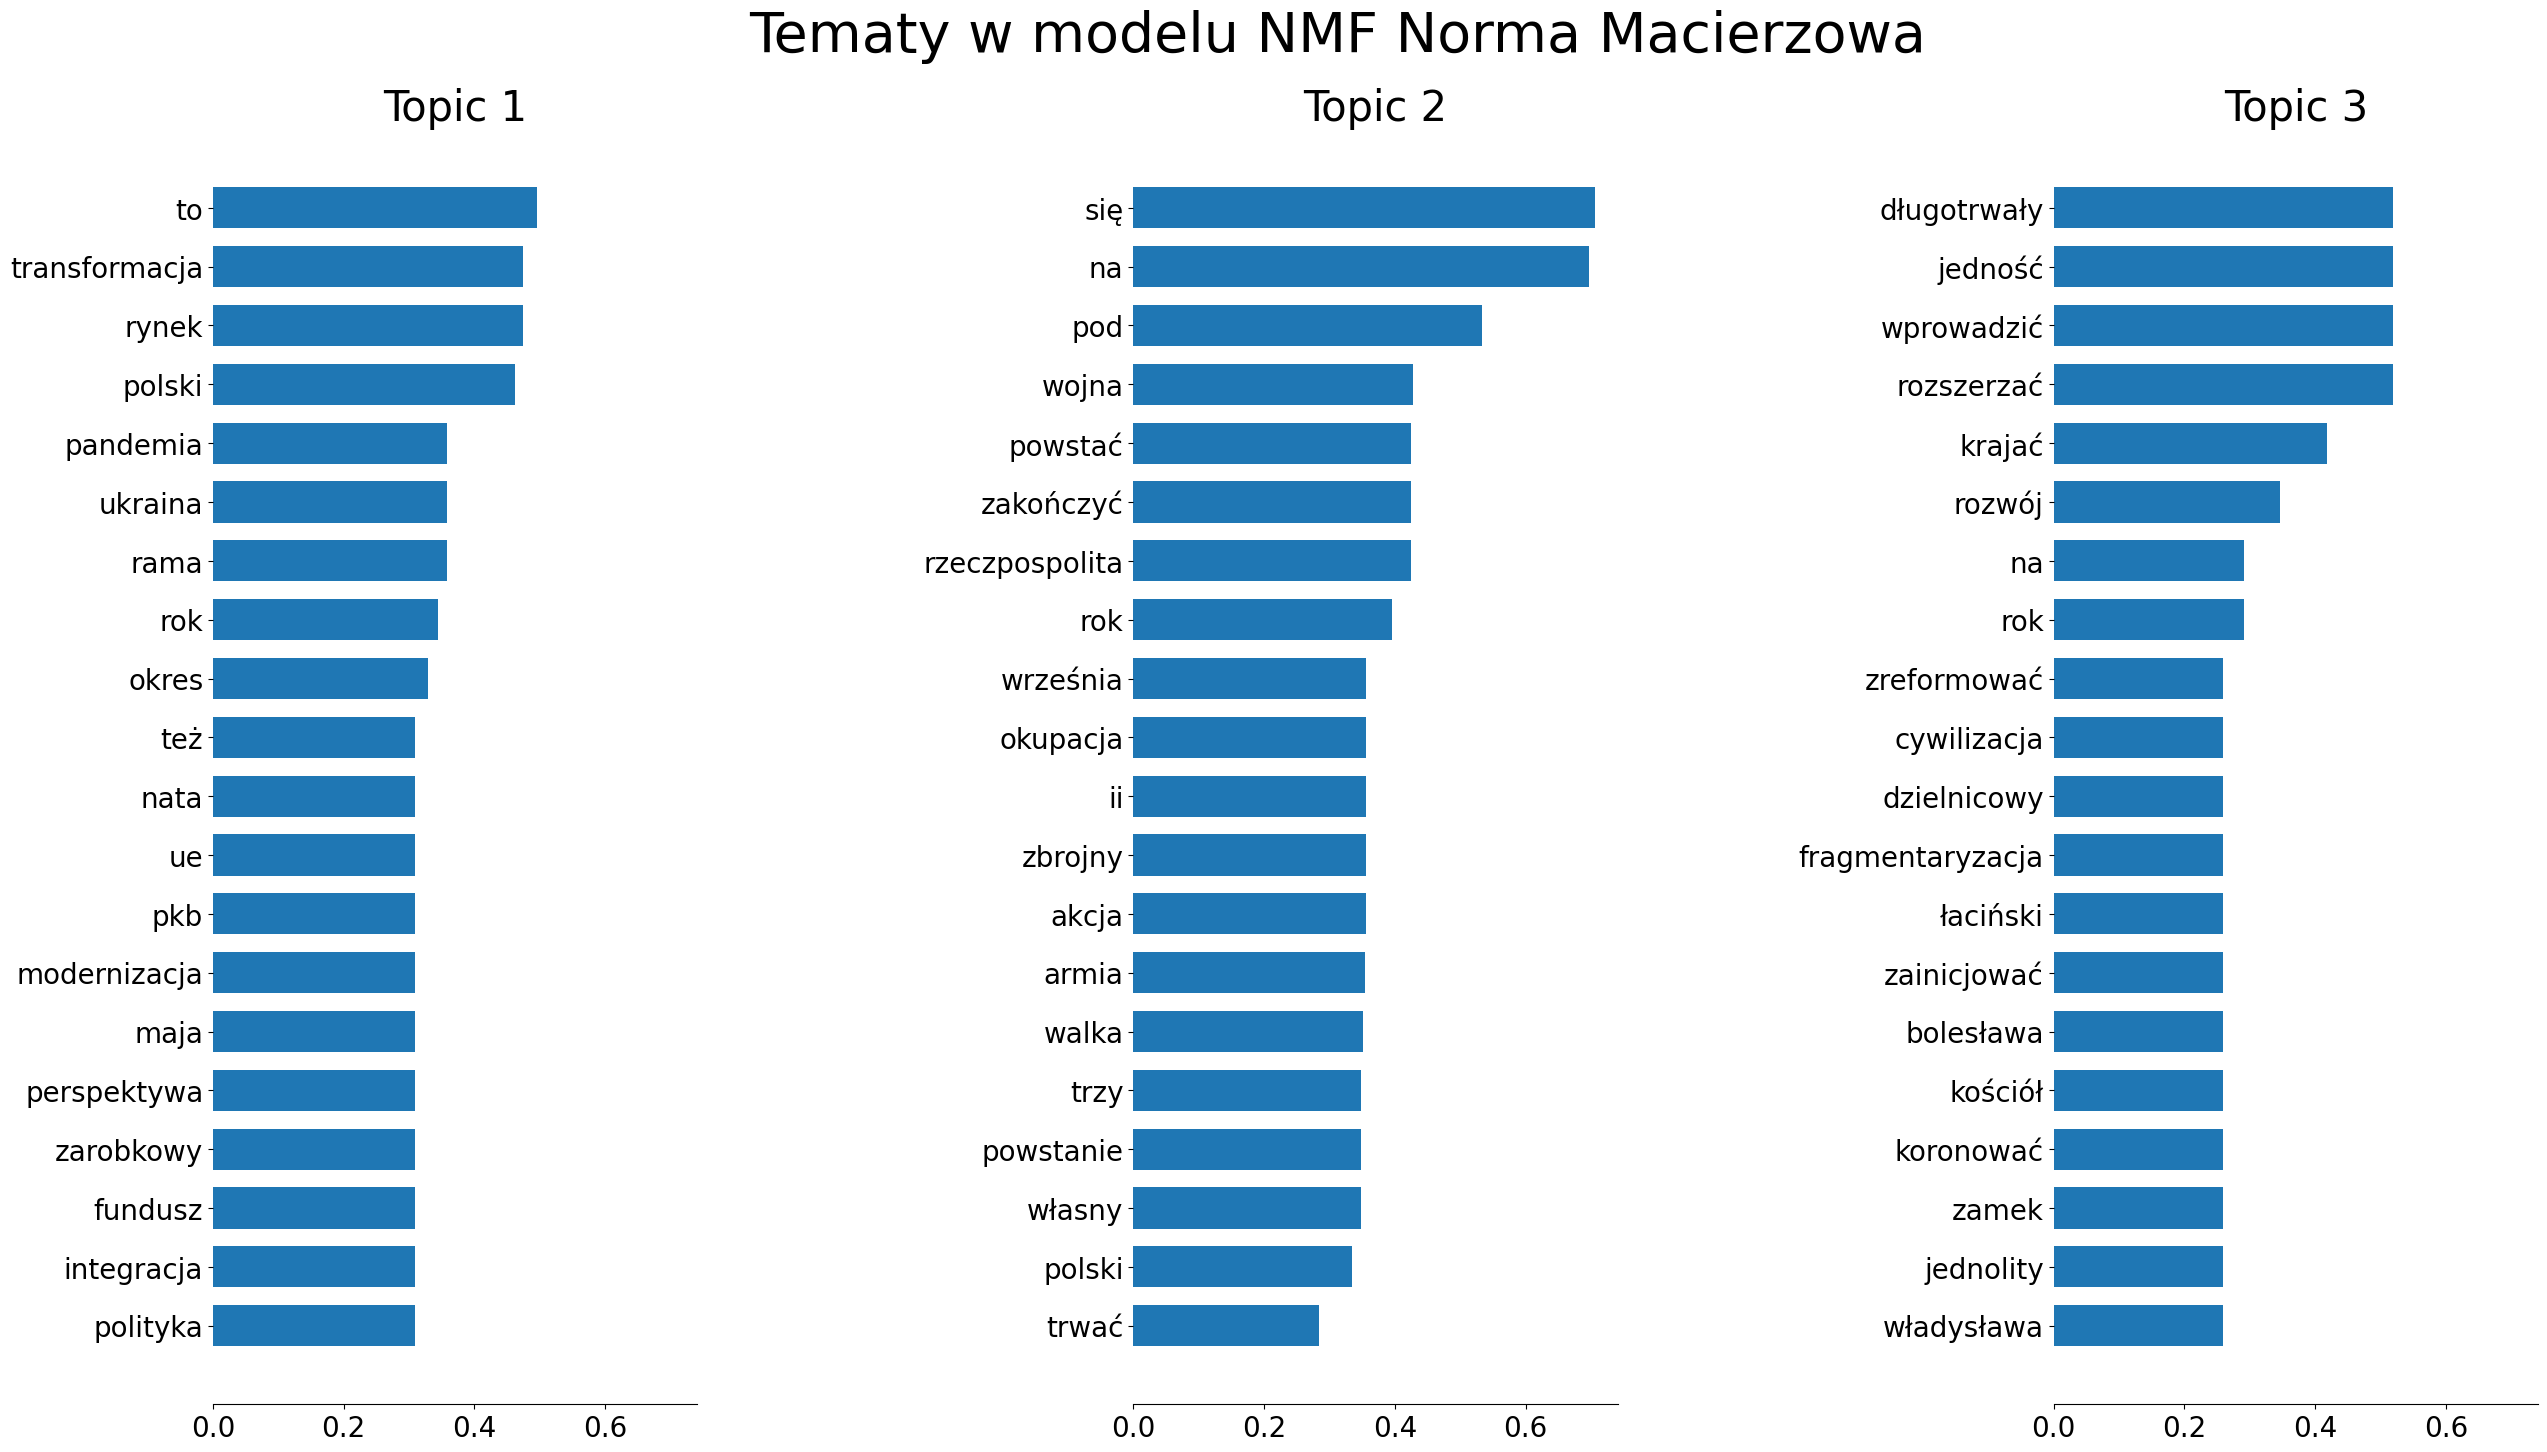

In [107]:
nmf_fm = NMF(
    n_components=n_components,
    random_state = 1, 
    alpha_H = .00005,
    alpha_W = .00005,
    l1_ratio = .5
)
nmf_fm.fit(counts_tfidf)
plot_top_words(nmf_fm, feature_names, n_top_features, "Tematy w modelu NMF Norma Macierzowa", size)

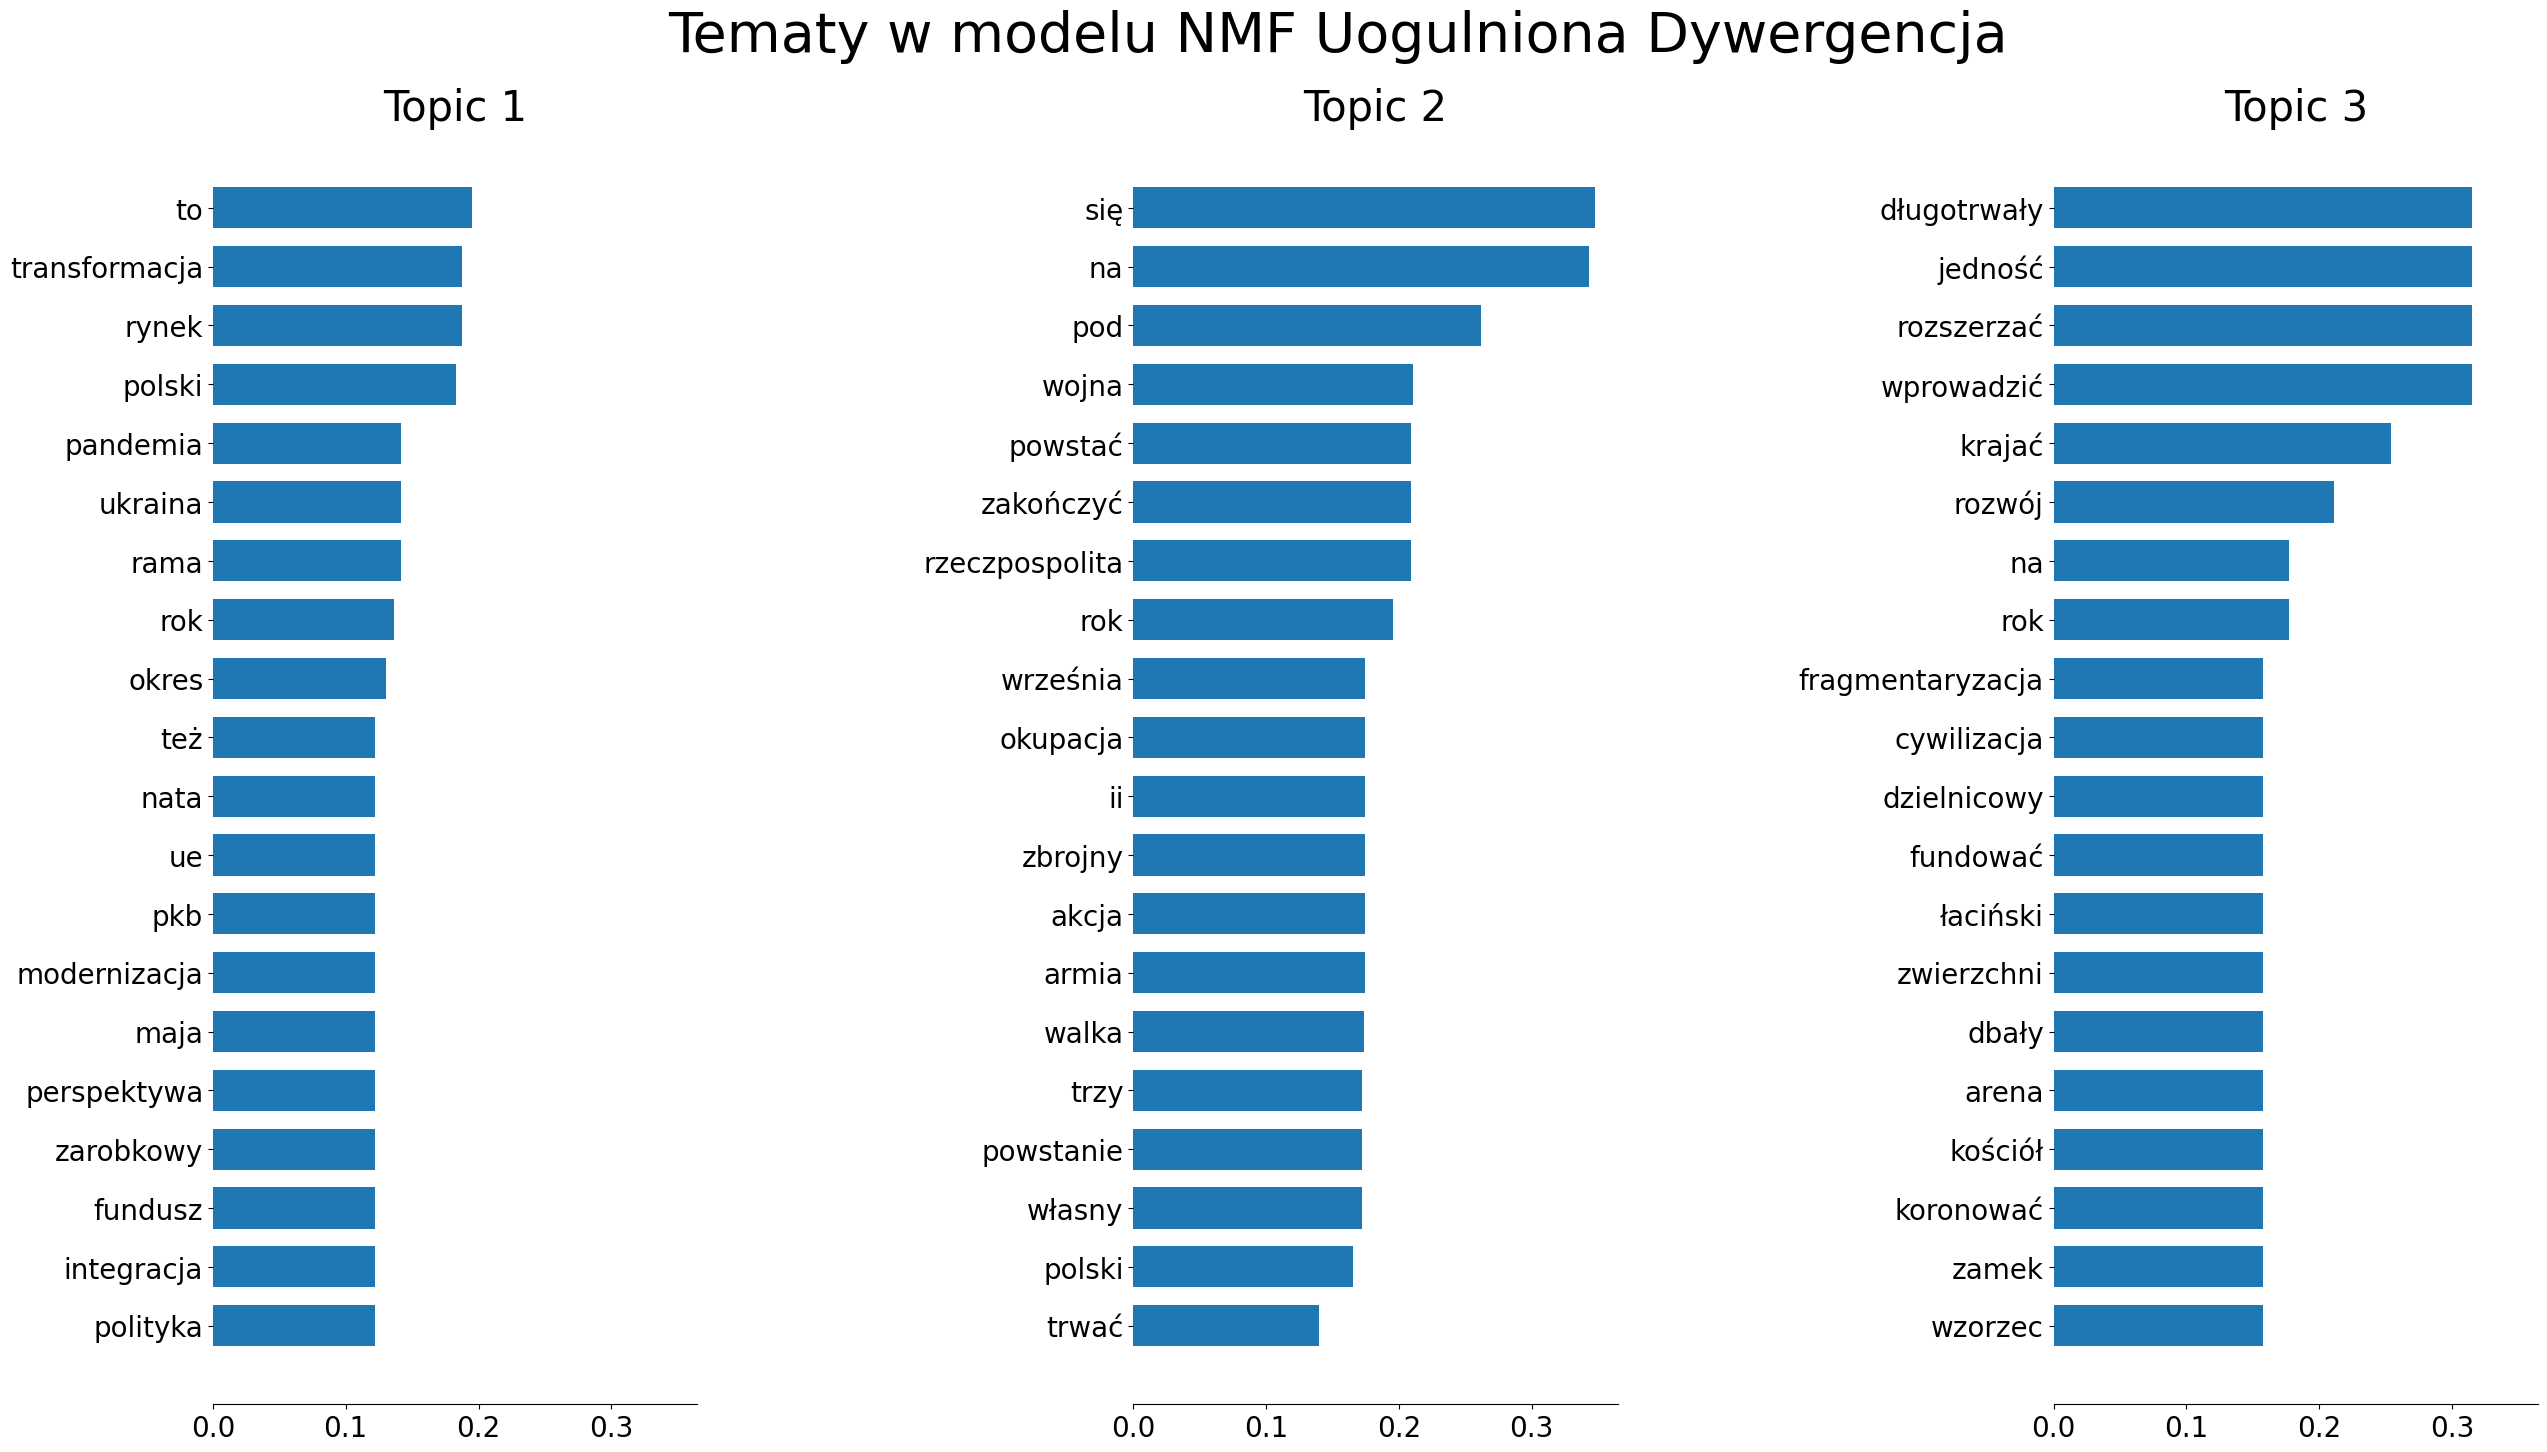

In [108]:
nmf_kl = NMF(
    n_components = n_components,
    random_state = 1, 
    beta_loss = 'kullback-leibler',
    solver = 'mu',
    max_iter = 1000,
    alpha_H = .00005,
    alpha_W = .00005,
    l1_ratio = .5
)
nmf_kl.fit(counts_tfidf)
plot_top_words(nmf_kl, feature_names, n_top_features, "Tematy w modelu NMF Uogulniona Dywergencja", size)

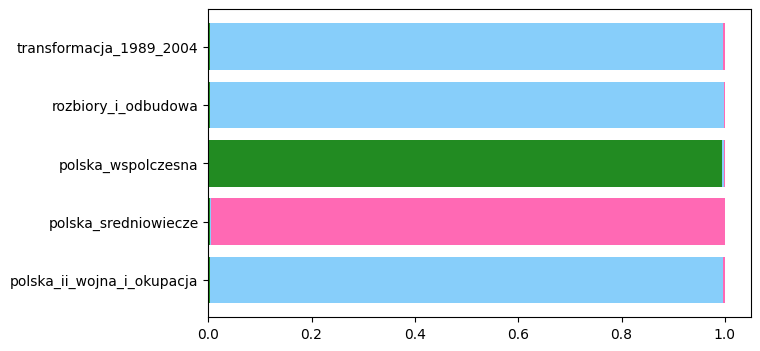

In [109]:
docs_topics = pd.DataFrame(lda.transform(counts_tf), columns=['Topic 1', 'Topic 2', 'Topic 3'])
docs_topics.index = [file_name.replace(".txt", "") for file_name in file_names]
plt.figure(figsize=(7, 4))
colors = ['forestgreen', 'lightskyblue', 'hotpink']
left = [0] * len(docs_topics)
for i, col in enumerate(docs_topics.columns):
    plt.barh(docs_topics.index, docs_topics[col], left = left, label = col, color = colors[i])
    left=[left[j] + docs_topics[col].iloc[j] for j in range(len(docs_topics))]

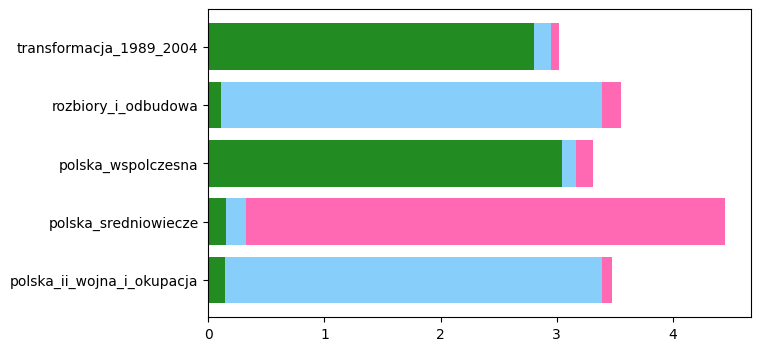

In [110]:
docs_topics = pd.DataFrame(nmf_fm.transform(counts_tf), columns=['Topic 1', 'Topic 2', 'Topic 3'])
docs_topics.index = [file_name.replace(".txt", "") for file_name in file_names]
plt.figure(figsize = (7, 4))
colors = ['forestgreen', 'lightskyblue', 'hotpink']
left = [0] * len(docs_topics)
for i, col in enumerate(docs_topics.columns):
    plt.barh(docs_topics.index, docs_topics[col], left = left, label = col, color = colors[i])
    left=[left[j] + docs_topics[col].iloc[j] for j in range(len(docs_topics))]

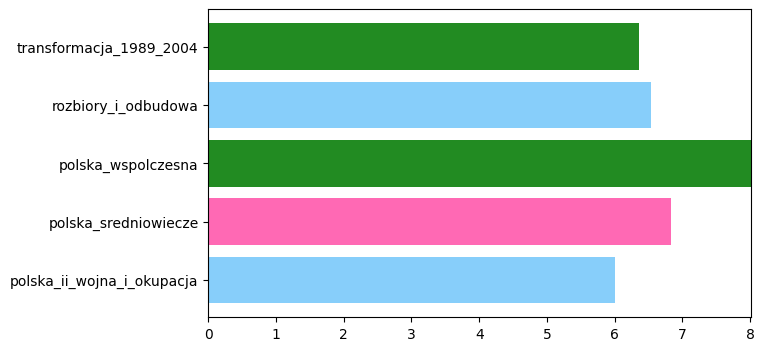

In [111]:
docs_topics = pd.DataFrame(nmf_kl.transform(counts_tf), columns=['Topic 1', 'Topic 2', 'Topic 3'])
docs_topics.index = [file_name.replace(".txt", "") for file_name in file_names]
plt.figure(figsize = (7, 4))
colors = ['forestgreen', 'lightskyblue', 'hotpink']
left = [0] * len(docs_topics)
for i, col in enumerate(docs_topics.columns):
    plt.barh(docs_topics.index, docs_topics[col], left = left, label = col, color = colors[i])
    left=[left[j] + docs_topics[col].iloc[j] for j in range(len(docs_topics))]

# Analiza skupień

In [112]:
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)
    dendrogram(linkage_matrix, **kwargs)

In [113]:
n_docs = len(file_names)
cs = cosine_similarity(counts_tfidf, counts_tfidf).flatten().reshape(n_docs, n_docs)
cs

array([[1.        , 0.07434677, 0.06886388, 0.14127129, 0.07310146],
       [0.07434677, 1.        , 0.09353322, 0.09396244, 0.07728409],
       [0.06886388, 0.09353322, 1.        , 0.0636372 , 0.11490245],
       [0.14127129, 0.09396244, 0.0636372 , 1.        , 0.0768437 ],
       [0.07310146, 0.07728409, 0.11490245, 0.0768437 , 1.        ]])

In [114]:
clusering = AgglomerativeClustering(
    n_clusters = 3,
    metric = "euclidean",
    linkage = "ward",
    compute_distances = True
).fit(cs)
clusering.labels_

array([1, 2, 0, 1, 0])

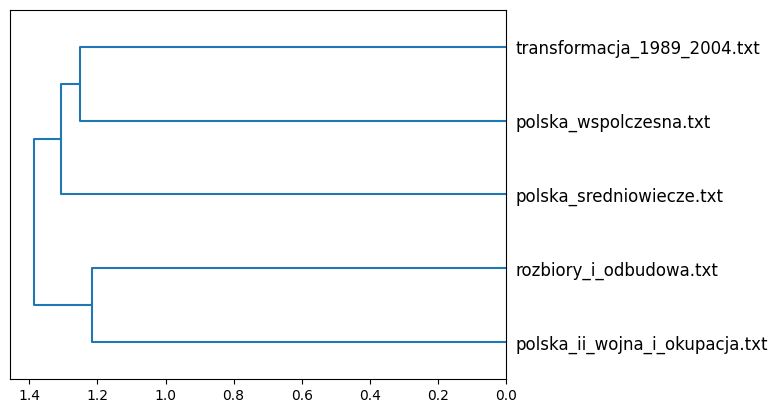

In [115]:
plot_dendrogram(
    clusering,
    labels = file_names,
    truncate_mode = 'level',
    orientation = 'left'
)
plt.show()

In [116]:
n_docs = len(file_names)
ed = euclidean_distances(counts_tf, counts_tf).flatten().reshape(n_docs, n_docs)
ed

array([[ 0.        , 16.79285562, 17.20465053, 16.61324773, 16.70329309],
       [16.79285562,  0.        , 16.37070554, 16.85229955, 15.84297952],
       [17.20465053, 16.37070554,  0.        , 17.54992877, 15.90597372],
       [16.61324773, 16.85229955, 17.54992877,  0.        , 16.82260384],
       [16.70329309, 15.84297952, 15.90597372, 16.82260384,  0.        ]])

In [117]:
clusering = AgglomerativeClustering(
    n_clusters = 3,
    metric = "precomputed",
    linkage = "complete",
    compute_distances = True
).fit(ed)
clusering.labels_

array([2, 0, 0, 1, 0])

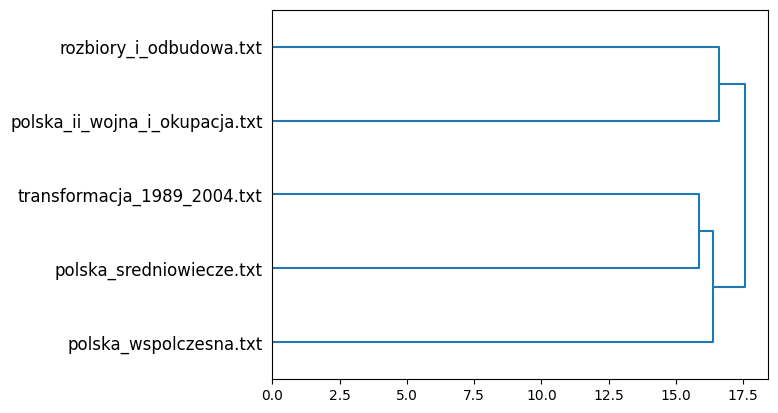

In [118]:
plot_dendrogram(
    clusering,
    labels = file_names,
    truncate_mode = 'level',
    orientation = 'right'
)
plt.show()

# N-gramy

In [119]:
documents_tokenized = {}
for key in documents:
    documents_tokenized[key] = word_tokenize(documents[key], language = 'polish')
print(json.dumps(documents_tokenized, indent = 4, ensure_ascii = False))  

{
    "polska_ii_wojna_i_okupacja.txt": [
        "wyzwanie",
        "egzystencjalny",
        "ii",
        "rzeczpospolita",
        "ii",
        "wojna",
        "światowy",
        "rozpocząć",
        "września",
        "rok",
        "agresja",
        "niemiecki",
        "września",
        "sowiecki",
        "kampania",
        "wrześniowy",
        "choć",
        "zakończyć",
        "się",
        "militarny",
        "klęska",
        "pokazać",
        "heroizm",
        "polski",
        "żołnierz",
        "pod",
        "Westerplatte",
        "Wizna",
        "Kocek",
        "okupacja",
        "hitlerowski",
        "przynieść",
        "systematyczny",
        "ludobójstwo",
        "plan",
        "generalplan",
        "ost",
        "egzekucja",
        "w",
        "Palmiry",
        "zagłada",
        "żyd",
        "w",
        "Treblinka",
        "Sobibór",
        "równocześnie",
        "trwać",
        "opora",
        "cywilny",
        "zbrojny",
 

polska_ii_wojna_i_okupacja.txt


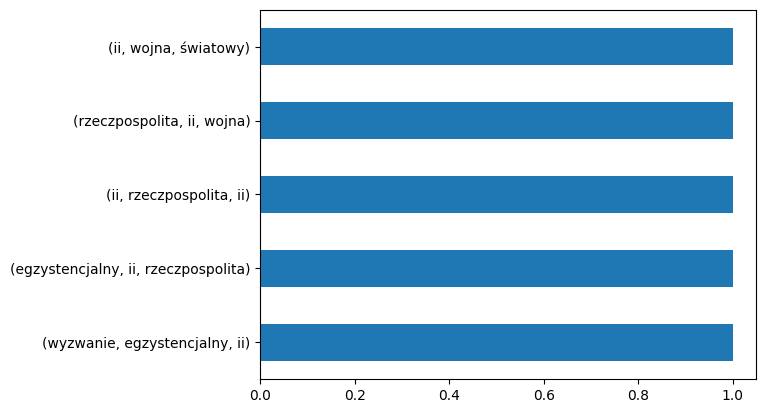

polska_sredniowiecze.txt


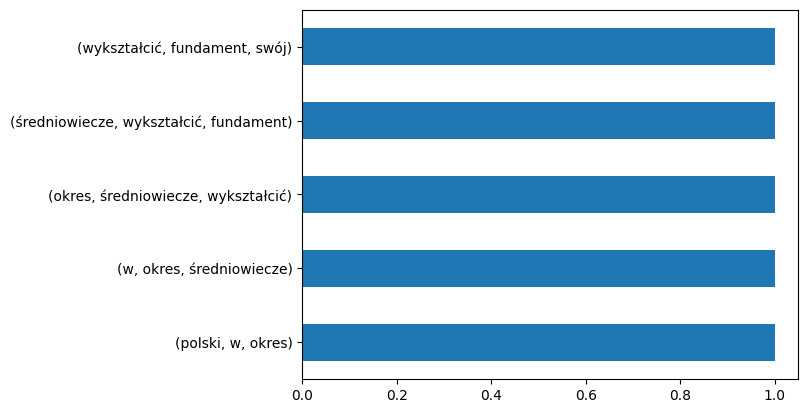

polska_wspolczesna.txt


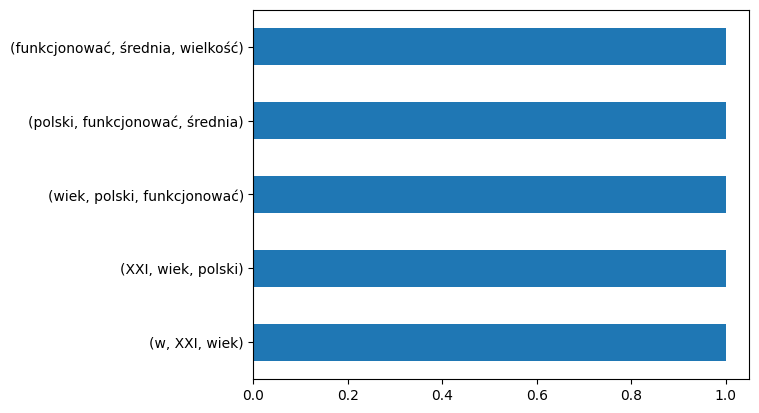

rozbiory_i_odbudowa.txt


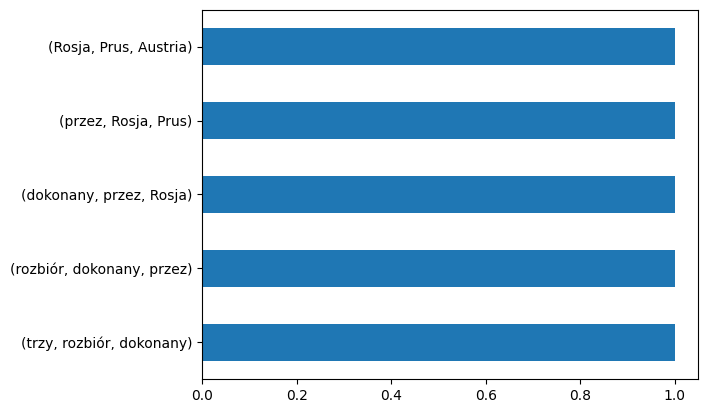

transformacja_1989_2004.txt


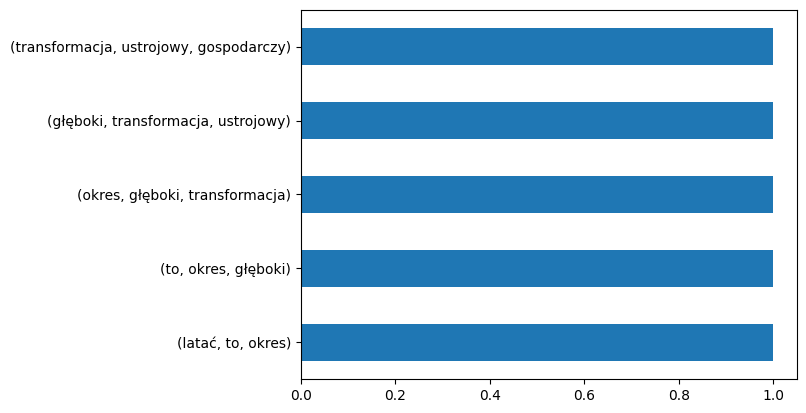

In [120]:
for title in documents_tokenized:
    n_gram = pd.Series(ngrams(documents_tokenized[title], 3)).value_counts()
    print(title)
    n_gram[:5].plot.barh()
    plt.show()

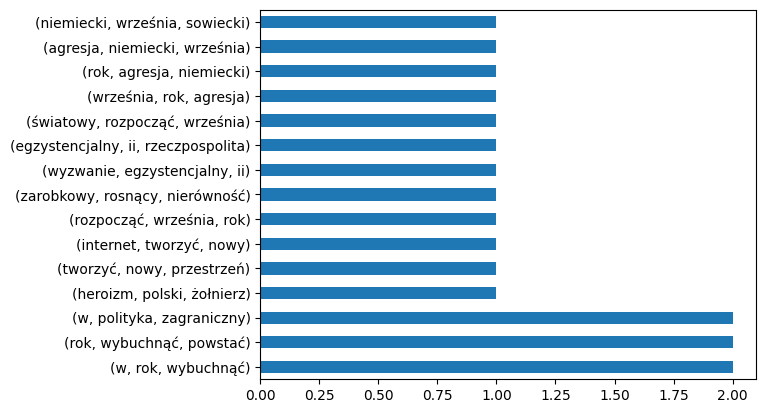

In [121]:
texts = ' '.join(docs['content']).split(" ")
n_gram = pd.Series(ngrams(texts, 3)).value_counts()
n_gram[:15].plot.barh()
plt.show()

# Wnioski końcowe

## Wnioski z analizy

1. **Przygotowanie korpusu**  
   Stworzono pięć rozbudowanych streszczeń obejmujących różne epoki historii Polski – od średniowiecza po czasy współczesne. Każdy tekst liczy kilkaset słów i koncentruje się na odrębnym wycinku dziejów.

2. **Proces czyszczenia**  
   - Wszystkie dokumenty sprowadzono do małych liter i pozbawiono znaków interpunkcyjnych.  
   - Zastosowano lematyzację za pomocą Morfeusza 2, co zredukowało odmiany fleksyjne do form podstawowych.  
   - Usunięto słowa funkcyjne na podstawie własnej listy stop-words, dzięki czemu w korpusie pozostały głównie tokeny niosące treść.

3. **Wizualizacja słownictwa**  
   Word-cloudy wygenerowane osobno dla każdego streszczenia uwidoczniły słowa kluczowe typowe dla danej epoki (np. *„wojna”, „września”, „armia”* w tekście o II wojnie; *„pandemia”, „ukraina”, „fundusz”* w części współczesnej). Jednocześnie pokazały, że wyrazy *„polski”* i *„rok”* dominują we wszystkich dokumentach.

4. **Tematy ukryte w korpusie**  
   Modele LDA oraz NMF podzieliły korpus na trzy zbliżone tematy:  
   - **Współczesność i transformacja** – słowa związane z pandemią, rynkiem oraz sytuacją geopolityczną.  
   - **Okres II wojny światowej** – leksyka dotycząca walki, okupacji i powstań.  
   - **Średniowieczne początki państwa** – terminy odnoszące się do jedności, rozwoju i struktur wczesnej Polski.  
   Zbieżność wyników obu algorytmów potwierdziła, że nawet niewielki, dobrze przygotowany zbiór dokumentów pozwala uchwycić czytelne wątki tematyczne.

5. **Klasteryzacja hierarchiczna**  
   Analiza odległości kosinusowej między wektorami tekstów zgrupowała streszczenia dokładnie według epok, co spójnie pokryło się z wynikami modelowania tematów.

W efekcie cały łańcuch – od tworzenia streszczeń przez czyszczenie tekstu po modelowanie – wykazał, że starannie przygotowane dane umożliwiają wychwycenie kluczowych motywów historycznych już przy niewielkiej liczbie dokumentów.
